In [1]:
import os
os.chdir('..')

In [2]:
from thefuzz import process
import cn2an
import logging
import re
from utils import pre_process, pre_process_without_n, printWithColor, standerlize_一般政策性内容
from extraction import find_一般政策语言_rule_base
import pandas as pd
import matplotlib.pyplot as plt

/Users/ender_yang/opt/anaconda3/envs/lainchain/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

def find_权宜处理_rule_base(docs, 一般政策性内容):
    """
    Return the sentences that match 权宜处理 keywords using regular expression and fuzzy matching.

    Returns:
        list of tuple: The sentences that match 权宜处理 keywords and the matched keywords.
        list of tuple: The index of the matched sentences in the original text and the matched keywords.
    """
    # Ignore the warnings
    logging.getLogger().setLevel(logging.ERROR)
    
    # We need to standardize the 一般政策性内容 to avoid any characters at the beginning of the sentence
    一般政策性内容 = standerlize_一般政策性内容(一般政策性内容)
    
    # Define keywords for regular expression
    keywords = ["结合.*?实际", "根据.*?实际", "因地制宜"]
    pattern = re.compile('|'.join(keywords))
    
    # Define keywords for fuzzy matching
    keywords_fuzzy = ["结合实际", "根据实际", "根据实际情况", "结合实际情况", "结合本地实际", "根据本地实际"]
    
    # Preprocess the document to separate it into paragraphs
    paragraphs = pre_process(docs)
    
    matched_paragraphs = []

    # First loop: Search for matches in each paragraph
    for paragraph in paragraphs:
        # Check if the paragraph is in 一般政策性内容
        clean_paragraph = re.sub(r'\s+', '', paragraph)
        if clean_paragraph in 一般政策性内容:
            continue
        
        match = pattern.search(paragraph)
        if match:
            matched_paragraphs.append((paragraph.strip(), match.group()))
        else:
            best_match = process.extractOne(paragraph, keywords_fuzzy)
            if  best_match[1] >= 60:
                matched_paragraphs.append((paragraph.strip(), best_match[0]))

    # Find the indices of matched paragraphs in the original document
    matched_paragraphs_index = []
    for sentence in matched_paragraphs:
        begin_index = docs.find(sentence[0])
        end_index = begin_index + len(sentence[0])
        matched_paragraphs_index.append((begin_index, end_index))
        
    return matched_paragraphs, matched_paragraphs_index

## Demonstration for using find_权宜处理_rule_base() function ##

$\textbf{We first read .txt file randomly from samples folder}$

In [4]:
file_sample = os.listdir('sample')[15]
docs = open(f'sample/{file_sample}', 'r').read()

$\textbf{Since we need 一般政策性内容 content, so we first extract 一般政策性内容}$

In [5]:
def get_一般政策语言(docs):
    matched_paragraphs_一般政策语言, _ = find_一般政策语言_rule_base(docs)
    一般政策语言_list = []
    for 一般政策语言, _ in matched_paragraphs_一般政策语言:
        一般政策语言_list += [一般政策语言]
        
    return 一般政策语言_list

In [6]:
# we can check the 一般政策语言 content
一般政策语言_list = get_一般政策语言(docs)
print(一般政策语言_list)

['\u3000第一章\u3000总则', '\u3000\u3000第一条\u3000为规范文物房屋征收和流转行为，保障被征收文物房屋所有权人（以下简称被征收人）和流转文物房屋使用权人的合法权益，加强文物房屋保护利用，根据《中华人民共和国民法典》《中华人民共和国文物保护法》《中华人民共和国土地管理法》《中华人民共和国城乡规划法》等法律、法规，参照《中共中央办公厅 国务院办公厅印发关于加强文物保护利用改革的若干意见》、《中共永嘉县委 永嘉县人民政府关于印发＜永嘉县保障性安居工程（四策合一）建设管理试行办法＞的通知》（永委发〔2013〕42号）等文件规定，结合永嘉县文物保护工作实际情况，制定本实施办法', '\u3000\u3000第二条\u3000本办法所称的文物房屋是指县级文物保护单位以上等级的民居类文物建筑', '\u3000\u3000第三条\u3000本办法适用于永嘉县范围内的合法被征收所有权的文物房屋（以下简称被征收房屋，包括经认定视同合法的被征收房屋）的补偿安置，以及对依法流转文物房屋使用权的奖励', '\u3000\u3000第四条\u3000农业户口的被征收房屋所有权人已按政策规定实行安置补偿的，不再享受农村一户一宅的宅基地审批政策']


## Now we can call the function find_权宜处理_rule_base() ##

In [7]:
matched_paragraphs, matched_paragraphs_index = find_权宜处理_rule_base(docs, 一般政策语言_list)

$\textbf{We can now check the content that we retrieved from the file and its corresponding reasons.}$

In [8]:
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(matched_paragraphs, columns=['Retrieve Info', 'Reason'])
df.head(10)

,Retrieve Info,Reason
0,具体根据当地乡镇（街道）提供的安置方式，结合实际情况由被征收人选择其中1种方式安置,根据当地乡镇（街道）提供的安置方式，结合实际


$\textbf{We can also check where is the sentence}$

In [9]:
printWithColor(docs, matched_paragraphs_index)

    【法宝引证码】 CLI.12.4913500
原文链接：https://www.pkulaw.com/lar/a2482b835c318b32a88380fdde68f0d0bdfb.html
永嘉县人民政府办公室关于印发永嘉县文物房屋征收和流转补偿实施办法(试行)的通知
永嘉县人民政府办公室关于印发永嘉县文物房屋征收和流转补偿实施办法（试行）的通知

（永政办发〔2020〕47号）

各功能区管委会，各乡镇（街道）人民政府（办事处），县政府直属各单位：

　　《永嘉县文物房屋征收和流转补偿实施办法（试行）》已经县政府第55次常务会议审议通过，现印发给你们，请遵照执行。
永嘉县人民政府办公室

　　2020年11月9日
永嘉县文物房屋征收和流转补偿实施办法（试行）
　第一章　总则
　　第一条　为规范文物房屋征收和流转行为，保障被征收文物房屋所有权人（以下简称被征收人）和流转文物房屋使用权人的合法权益，加强文物房屋保护利用，根据《中华人民共和国民法典》《中华人民共和国文物保护法》《中华人民共和国土地管理法》《中华人民共和国城乡规划法》等法律、法规，参照《中共中央办公厅 国务院办公厅印发关于加强文物保护利用改革的若干意见》、《中共永嘉县委 永嘉县人民政府关于印发＜永嘉县保障性安居工程（四策合一）建设管理试行办法＞的通知》（永委发〔2013〕42号）等文件规定，结合永嘉县文物保护工作实际情况，制定本实施办法。
　　第二条　本办法所称的文物房屋是指县级文物保护单位以上等级的民居类文物建筑。
　　第三条　本办法适用于永嘉县范围内的合法被征收所有权的文物房屋（以下简称被征收房屋，包括经认定视同合法的被征收房屋）的补偿安置，以及对依法流转文物房屋使用权的奖励。
　　第四条　农业户口的被征收房屋所有权人已按政策规定实行安置补偿的，不再享受农村一户一宅的宅基地审批政策。

　第二章　安置方式与计算标准
　　第五条　被征收房屋实行属地产权安置、货币补偿安置、跨区域异地产权安置、宅基地置换安置（以下简称地基安置）等4种方式，其中地基安置仅限于确因条件限制不能集中安置的零星农民自建房。其他附属配套用房建筑物、构建物（包括道坦）等有文物价值的，需经第三方评估后予以货币补偿。具体根据当地乡镇（街道）提供的安置方式，结合实际情况由被征收人选择其中1种方式安置。
　　第六条　被征收人选择属

## Now we can run batch processing on our sample data ##

In [10]:
def run_batch(path_to_folder):
    return_df = pd.DataFrame(columns=['File Name', 'Retrieve Info', 'Reason', 'Original Text Length','Retrieve Info Length', '一般政策语言'])
    files = os.listdir(path_to_folder)
    for file in files:
        if not file.endswith('.txt'):
            continue
        docs = open(f'{path_to_folder}/{file}', 'r').read()
        一般政策语言_list = get_一般政策语言(docs)
        
        matched_paragraphs, matched_paragraphs_index = find_权宜处理_rule_base(docs, 一般政策语言_list)
        matched_paragraphs_list = "\n".join([paragraph[0] for paragraph in matched_paragraphs])
        reson_list = "\n".join([paragraph[1] for paragraph in matched_paragraphs])
        
        return_df.loc[len(return_df)] = [file, matched_paragraphs_list , reson_list, len(docs), len(matched_paragraphs_list), "\n".join(一般政策语言_list)]
    
    return return_df


In [11]:
df = run_batch('sample')
# we chack first 5 files
df.head(5)
# you can save this to csv
# df.to_csv('path/to/your/result.csv', index=False)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言
0,吉林保监局关于安邦人寿保险股份有限公司吉林...(FBM-CLI.12.1776690).txt,,,485,0,你公司《安邦人寿保险股份有限公司吉林分公司关于设立安邦人寿保险股份有限公司辽源中心支公司的请示》（安邦寿吉发〔2016〕031号）及其补正材料已收悉。经审查，现通知如下：
1,北京市人民政府办公厅印发《关于在“十三五”...(FBM-CLI.12.1250419).txt,,,4421,0,为贯彻落实党中央、国务院关于打赢脱贫攻坚战的战略部署，确保率先全面建成小康社会，结合实际，现就本市在“十三五”时期对困难群众实施精准救助提出如下意见\n （一）指导思想\n 深入学习贯彻习近平总书记系列重要讲话和对北京工作的重要指示精神，牢固树立创新、协调、绿色、开放、共享的发展理念，将主动发现、严格管理、精准施救作为工作重点，强化救助响应，拓展服务方式，实现全过程监管，构建政府主导、社会参与的救助体系，切实让困难群众共享改革发展成果
2,山西省林业和草原局关于印发《退耕还林还草作...(FBM-CLI.12.4108330).txt,,,805,0,为进一步规范退耕还林还草管理，满足新时代退耕还林还草事业高质量发展的需要，国家林业和草原局制定了《退耕还林还草作业设计技术规定》和《退耕还林还草档案管理办法》（见附件1、2），请遵照执行。现提出如下要求：
3,北京市教育委员会、北京市经济和信息化局、北...(FBM-CLI.12.4087809).txt,现予发布，请结合实际，参照执行,结合实际,480,15,为深入贯彻党的十九大和十九届二中、三中、四中、五中全会精神，认真落实《教育信息化2.0行动计划》《首都教育现代化2035》等部署要求，统筹推进北京教育信息化工作，指导全市中小学校科学规范开展信息化建设，支撑首都教育高质量发展，市教委联合市经济和信息化局、市财政局制定了《北京市中小学校信息化建设规范（试行）》
4,吕梁市住房保障和城乡建设管理局关于转发山西...(FBM-CLI.12.1887683).txt,,,499,0,现将省住建厅晋建市字【2012】289号“山西省住房和城乡建设厅关于开展2012年度建筑业等5类企业动态考核评价工作的通知”转发给你们，建筑业一级、二级及设计施工一体化企业，监理企业，招标代理企业请遵照执行


In [12]:
# We can check if the Retrieve Info is in 一般政策语言
for index, row in df.iterrows():
    if row['Retrieve Info'] == '':
        continue
    
    Retrieve_Info = row['Retrieve Info'].split('\n')
    一般政策语言 = row['一般政策语言'].split('\n')
    
    for info in Retrieve_Info:
        if info in 一般政策语言:
            print(info)

$\textbf{Here we provide some statistics on the results}$

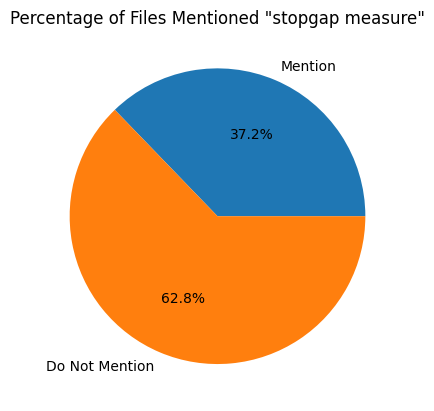

In [13]:
# We can show how many files have the retrieve info
is_mention = len(df[df['Retrieve Info'] != ''])
do_not_mention = len(df[df['Retrieve Info'] == ''])

fig, ax = plt.subplots()
ax.pie([is_mention, do_not_mention], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
plt.title('Percentage of Files Mentioned "stopgap measure"')
plt.show()


$\textbf{To analyze the results of retrieval text, we need to remove the policy that do not have retrieval info}$

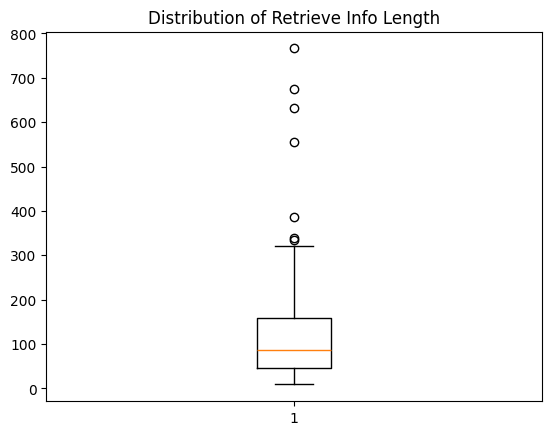

In [14]:
# Box plot to show the distribution of retrieve info length
df_temp = df.copy()
# we drop all the rows that do not have retrieve info
df_temp = df_temp[df_temp['Retrieve Info'] != '']
retrieve_info_length = df_temp['Retrieve Info'].apply(lambda x: len(x))
plt.boxplot(retrieve_info_length)
plt.title('Distribution of Retrieve Info Length')
plt.show()

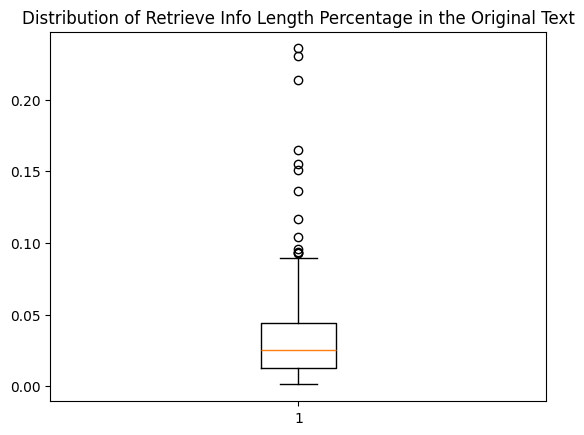

In [15]:
# we can also see the distribution that to what percentage of the document is the retrieve info
df_temp['Retrieve Info Length Percentage'] = df_temp['Retrieve Info Length'] / df_temp['Original Text Length']
plt.boxplot(df_temp['Retrieve Info Length Percentage'])
plt.title('Distribution of Retrieve Info Length Percentage in the Original Text')
plt.show()

In [16]:
# let's show the most three outliar for the retrieve info length
df_temp.sort_values('Retrieve Info Length', ascending=False).head(3)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言,Retrieve Info Length Percentage
244,广州市人民政府办公厅关于加强农村住宅建设管...(FBM-CLI.12.1643122).txt,为实施乡村振兴战略，推动我市农村住宅建设规范化管理、便捷化服务，根据中央、省关于深化农村宅基地管理制度改革的要求，结合我市实际并经市人民政府同意，制定本实施意见\n人均土地少、不能保障一户拥有一处宅基地的地区，各区可根据辖区实际制定建筑层数、建筑高度控制标准\n村民公寓式住宅建设首先要考虑历史欠房户和新增分户需求，因地制宜、集中布局，体现节约集约用地和方便生产生活的原则，按照城市居住小区标准进行集中建设\n五、因地制宜，分类施策\n结合国土空间规划体系改革，市规划和自然资源部门指导各区从农村实际出发，尊重村（居）民意愿，体现地方和农村特色，结合各区地质灾害防治规划和地质灾害危险性调查评估情况，因地制宜编制或修编村庄规划或控制性详细规划，预留一定的建设用地规模解决历史遗留宅基地问题，保障村（居）民新增分户建房的合理需求，合理布局农村生产、生活和生态用地，鼓励农民集中建房，切实避开危险区域，形成相对集中、集约高效、安全可靠的村庄用地建设布局\n各区人民政府负责组织开展农民住房需求调查摸底工作，可根据本实施意见制定本辖区具体操作细则\n市住房城乡建设部门负责组织编制《广州市美丽乡村民居设计图集》，供广大村（居）民免费使用，做好推广普及工作，指导村（居）民科学使用图集，并根据实际情况及时更新；加强对村民公寓、村公共服务设施等建设项目设计和建设的指导；督促各区人民政府落实农村削坡建房整治工作\n各区人民政府可根据本区的实际情况将村（居）民申请建设个人住宅涉及的现状地形图规划核查、规划放线、用地规划核实等费用纳入本级财政预算，并对符合条件的农村住宅建设给予住房设计费用和建筑风貌补助\n对建设村民公寓“上楼”居住的，节余用地优先安排村公共服务设施后，可以作为村集体经济发展用地，并给予一定的资金支持，具体标准由各区人民政府结合辖区实际制定,根据中央、省关于深化农村宅基地管理制度改革的要求，结合我市实际\n根据辖区实际\n因地制宜\n因地制宜\n结合国土空间规划体系改革，市规划和自然资源部门指导各区从农村实际\n根据本地实际\n根据实际\n根据本区的实际\n结合辖区实际,9028,766,（一）基本原则\n 1.坚持问题导向\n聚焦我市农村住宅建设中存在的难点问题，分类研究，多渠道推动农村用地建房选址布局合理化、管理程序规范化、事项标准化、审批便捷化\n 2.坚持分类施策\n根据不同的村庄类型、经济基础、民风民情、人文积淀等实际情况，在尊重农民意愿的基础上，因势利导，分类施策，有效破解各类难题\n 3.坚持盘活存量\n充分利用增减挂钩、拆旧复垦等政策，加大农村土地综合整治、宅基地整理、村庄拆改力度，改善农村人居环境，提高节约集约用地水平\n 4.坚持服务意识\n充分考虑农民生产生活需求，提供更多的便民、利民服务措施，不断提升农民获得感、幸福感、安全感\n 5.坚持共治共管\n重点整治农村“两违”、削坡建房以及造成住房安全隐患等问题，整合执法资源，强化协同联动，完善长效监管机制,0.084847
326,西安市医疗保障局关于印发西安市基本医疗保险...(FBM-CLI.12.5460359).txt,第四条 市医疗保险经办机构应当根据我市基本医疗保险基金收支预算总额，参考近三年各定点医疗机构服务提供情况和实际医疗费用发生情况，确定各定点医疗机构的医疗保险基金支付协议指标；各区县医疗保障部门要按照收支预算管理的有关规定和要求，同步做好由本区县负责结算工作的定点医疗机构总额控制指标的测算、核实和初步确定工作\n第七条 各定点医疗机构的协议指标根据医疗机构近三年的历史数据，结合医疗机构级别、类别、特点、服务范围、有效服务量等实际情况确定，并依据医疗保险政策变动、物价和医疗费用上涨等因素原则上每两年调整一次\n第九条 普通住院定额结算标准，由市医疗保险经办机构根据各定点医疗机构的不同级别、类别以及所承担的基本医疗保险服务量，参照近三年医疗费用实际支出水平，剔除不合理开支、考虑物价上涨等因素，按照“分组制定、同组同标准”的原则，合理确定各组定额结算标准，并报经市医疗保障局同意后确认公布\n医疗保险经办机构按月支付医疗费用时，根据协议指标结算，实际值低于协议指标的，按实际值计算支付的费用；实际值高于协议指标的，按协议指标计算支付的费用，并实行弹性结算\n第十四条 医疗保险经办机构与定点医疗机构在年终决算时，按照“结余奖励、合理超支分担”的精神，根据各定点医疗机构发生的符合基本医疗保险规定的合理医疗费用实际值与协议指标关系，按照下列规定结算：\n各级医疗保险经办机构要加强对医疗费用支出的审核，对不符合规定的医疗费用不予支付；对符合规定的费用要按照规定及时向医疗机构拨付医疗费用，不得无故延误或少拨，并可根据实际情况向定点医疗机构拨付一定数额的周转资金,根据我市基本医疗保险基金收支预算总额，参考近三年各定点医疗机构服务提供情况和实际\n根据医疗机构近三年的历史数据，结合医疗机构级别、类别、特点、服务范围、有效服务量等实际\n根据各定点医疗机构的不同级别、类别以及所承担的基本医疗保险服务量，参照近三年医疗费用实际\n根据协议指标结算，实际\n根据各定点医疗机构发生的符合基本医疗保险规定的合理医疗费用实际\n根据实际,4464,675,为保障我市基本医疗保险参保人员的基本医疗需求，规范医疗保险费用结算，提高基金使用效率，确保医疗保险制度长期可持续运行，根据《西安市人民政府办公厅关于印发西安市进一步深化基本医疗保险支付方式改革实施方案的通知》（市政办发〔2018〕114号）等有关规定，现制定《西安市基本医疗保险定点医疗机构费用结算管理办法》并印发给你们，请认真贯彻执行,0.151210
291,阜新市人民政府办公室关于印发阜新市食品安全...(FBM-CLI.12.1292987).txt,经市政府同意，现将《阜新市食品安全示范城市创建工作实施方案》印发给你们，请结合实际，认真组织实施\n各县区同步开展创建工作，因地制宜，紧紧抓住本辖区食品安全存在的重点难点，进一步夯实基层监管基础，有效防范食品安全风险，实现创建活动无空白、无死角\n盯住重点难点问题，坚持问题导向，因地制宜，积极创新工作方式、方法，探索食品安全治理新模式、新机制、新举措，提高治理效能，有效防范食品安全风险\n按照《食品药品监管总局关于印发全国食品药品监督管理机构执法基本装备配备指导标准的通知》（食药监财〔2014〕204号）和《食品药品监管总局关于印发食品药品监管乡镇（街道）派出机构办公业务用房建设指导意见的通知》（食药监财〔2014〕218号）要求，结合我市实际，建章立制，规范提高，全面提升基层市场监管所制度建设、队伍建设和软硬件建设水平\n市政府制定出台创建工作实施方案，召开会议、研究部署创建工作；各县区、市食安委各成员单位（以下简称成员单位）要按照市政府统一部署，统一思想，加强宣传、明确责任，要根据本方案，结合实际，制定本县区、本部门具体的实施方案和细则，明确任务，落实责任，全面展开创建工作，按时完成年度工作目标\n各县区和成员单位可根据实际制定具体奖励办法，对在创建工作中作出突出贡献的单位和人员予以奖励\n各县区、各部门要结合实际和特点，制定贴近百姓、贴近任务、贴近实效的宣传方案，广泛增进社会了解、凝聚社会共识，形成全市各界和广大群众支持创建、积极参与创建的良好氛围,结合实际\n因地制宜\n因地制宜\n结合我市实际\n根据本方案，结合实际\n根据实际\n结合实际,6792,631,按照国务院和省政府统一部署，依据《辽宁省人民政府关于进一步加强食品安全工作的意见》（辽政发〔2015〕42号）、《辽宁省人民政府食品安全委员会关于印发辽宁省食品安全城市创建三年行动计划的通知》（辽食安委发〔2016〕4号）、《辽宁省人民政府食品安全委员会办公室关于印发辽宁省食品安全示范城市管理与评价办法和评价细则（暂行）的通知》（辽食安办发〔2016〕4号，以下简称《办法和细则》），扎实推进食品安全示范城市创建工作，结合我市实际，制定本方案\n （一）指导思想\n全面贯彻落实党的十八大和十八届三中、四中、五中、六中全会，以及国务院“双创双安”试点工作现场会和辽宁省食品安全示范城市创建工作现场推进会精神，按照“四个最严”要求，以保障和改善民生为出发点，以创建食品安全示范城市为载体，全面实施食品安全战略\n督促各级政府落实属地责任，促进监管部门依法履职、企业依法诚信经营、社会各界积极参与、食品产业健康发展，加快形成严密高效、社会共治的食品安全治理体系，提升全市食品安全管理水平，推动食品安全整体形势持续稳定向好，确保人民群众吃得放心，全面提高食品安全满意度,0.092903


In [17]:
# we can also show the most three outliar for the retrieve info length percentage
df_temp.sort_values('Retrieve Info Length Percentage', ascending=False).head(3)

,File Name,Retrieve Info,Reason,Original Text Length,Retrieve Info Length,一般政策语言,Retrieve Info Length Percentage
226,青岛市水务管理局关于废止《青岛市河道采砂收...(FBM-CLI.12.3833522).txt,根据工作实际，结合我市河道采砂立法情况，经认真研究并征求有关部门意见，决定对《青岛市河道采砂收费管理实施细则》（青水发〔1992〕7号）予以废止，自公布之日起不再适用,根据工作实际,352,83,根据市规范性文件清理工作要求，市水利局对本部门制定发布的规范性文件进行了清理,0.235795
122,哈尔滨市农业委员会关于印发2014年全市主要农作...(FBM-CLI.12.1881049).txt,经广泛征求各地意见并参考各区、县（市）鉴评结果，根据《黑龙江省2014年主要粮食作物优质高产品种区域布局规划》的总体要求，按照优质、高产、抗病、适期成熟的原则，结合我市生产实际，提出了我市2014年三大作物玉米、大豆、水稻的主栽、搭配品种应用意见,根据《黑龙江省2014年主要粮食作物优质高产品种区域布局规划》的总体要求，按照优质、高产、抗病、适期成熟的原则，结合我市生产实际,533,123,现将此意见印发给你们，请各区、县（市）结合当地实际，制定本地区用种意见，准备适宜品种，安排2014年农业生产用种，同时加大对新品种的宣传力度，认真抓好良种良法的推广工作,0.230769
267,郑州市物价局关于郑州市贝斯特外语中学有关收...(FBM-CLI.12.423836).txt,根据省发改委、教育厅、劳动和社会保障厅《关于河南省民办学校收费管理暂行办法的通知》（豫发改收费[2005]1055号）精神，根据成本监审结果（郑价成审[2010]10号），结合你校实际，经研究决定你校有关收费标准如下：,根据省发改委、教育厅、劳动和社会保障厅《关于河南省民办学校收费管理暂行办法的通知》（豫发改收费[2005]1055号）精神，根据成本监审结果（郑价成审[2010]10号），结合你校实际,510,109,你单位《关于郑州市贝斯特外语中学有关收费标准的请示》收悉,0.213725


## We can also comparing the statistics results between two different labels ##

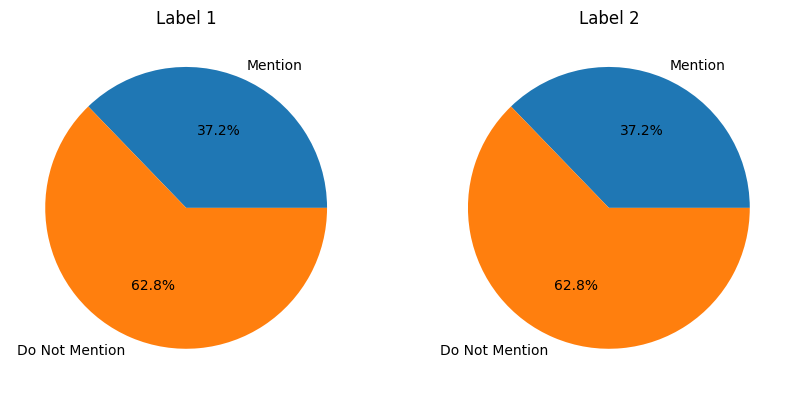

In [18]:
# To achieve this comparison, we need to folder to store the policy data for two labels respectively
# To avoid the relative path issue, We use absolute path here
path_to_folder_label1 = '/Users/ender_yang/Desktop/Spark/ds-ciss-policy-docs/task-a/sample'
path_to_folder_label2 = '/Users/ender_yang/Desktop/Spark/ds-ciss-policy-docs/task-a/sample'

df_label1 = run_batch(path_to_folder_label1)
df_label2 = run_batch(path_to_folder_label2)

# compare two bar chart
is_mention_label1 = len(df_label1[df_label1['Retrieve Info'] != ''])
do_not_mention_label1 = len(df_label1[df_label1['Retrieve Info'] == ''])
is_mention_label2 = len(df_label2[df_label2['Retrieve Info'] != ''])
do_not_mention_label2 = len(df_label2[df_label2['Retrieve Info'] == ''])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].pie([is_mention_label1, do_not_mention_label1], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
ax[0].set_title('Label 1')
ax[1].pie([is_mention_label2, do_not_mention_label2], labels=['Mention', 'Do Not Mention'], autopct='%1.1f%%')
ax[1].set_title('Label 2')
plt.show()

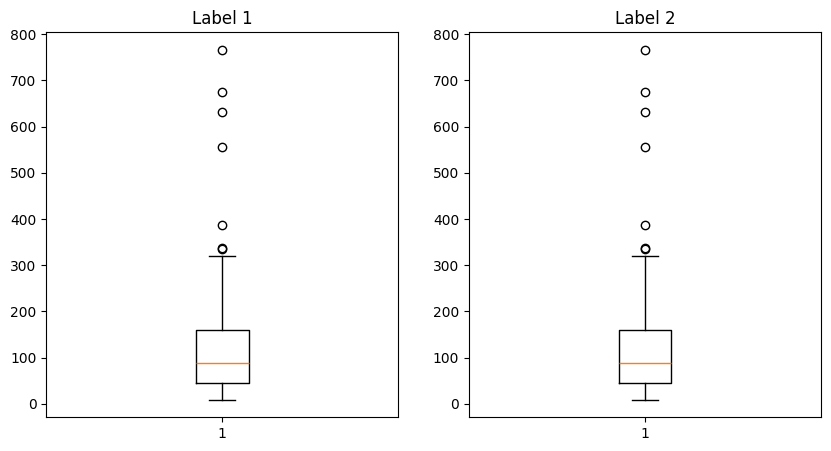

In [19]:
# We can also compare the distribution of retrieve info length
df_label1 = df_label1[df_label1['Retrieve Info'] != '']
df_label2 = df_label2[df_label2['Retrieve Info'] != '']

retrieve_info_length_label1 = df_label1['Retrieve Info'].apply(lambda x: len(x))
retrieve_info_length_label2 = df_label2['Retrieve Info'].apply(lambda x: len(x))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(retrieve_info_length_label1)
ax[0].set_title('Label 1')
ax[1].boxplot(retrieve_info_length_label2)
ax[1].set_title('Label 2')
plt.show()

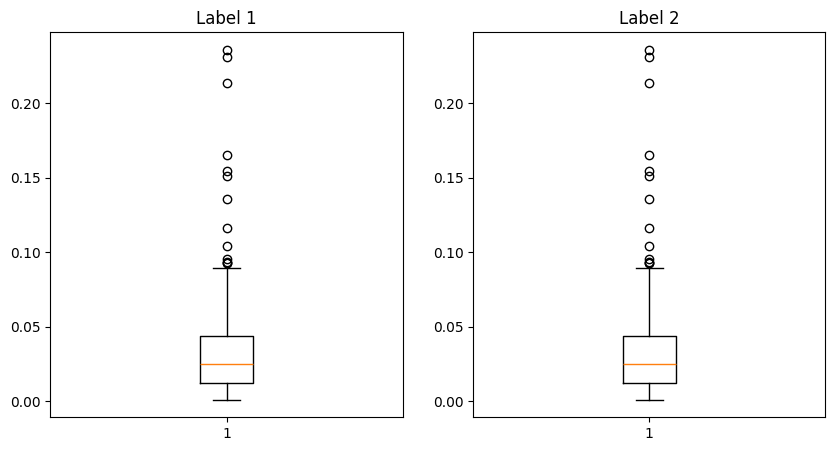

In [20]:
df_label1['Retrieve Info Length Percentage'] = df_label1['Retrieve Info Length'] / df_label1['Original Text Length']
df_label2['Retrieve Info Length Percentage'] = df_label2['Retrieve Info Length'] / df_label2['Original Text Length']

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].boxplot(df_label1['Retrieve Info Length Percentage'])
ax[0].set_title('Label 1')
ax[1].boxplot(df_label2['Retrieve Info Length Percentage'])
ax[1].set_title('Label 2')
plt.show()